# Incremental method

The following structure is investigated

```{figure} ./data_example_2_lecture_3/structure.svg
:align: center
:number:
```

In [1]:
import sympy as sym
sym.init_printing(use_latex='mathjax')
from IPython.display import display as ipy_display, Math

%config InlineBackend.figure_formats = ['svg']

def display(*objs):
    for obj in objs:
        if isinstance(obj, dict):
            lines = [f"{sym.latex(k)} &= {sym.latex(obj[k])}" for k in sorted(obj, key=lambda s: str(s))]
            ipy_display(Math(r"\begin{aligned}" + r"\\ ".join(lines) + r"\end{aligned}"))
        else:
            ipy_display(obj)

In [2]:
#import packages
import sympy as sym
import matplotlib.pyplot as plt

In [3]:
#Defines symbols and functions
q_L, x, = sym.symbols('q_L, x')
w = sym.Function('w')

EI = 20000
L = sym.S(5)
M_p = 100

In [4]:
# Define the ODE for the bending of the beam
ODE_bending = sym.Eq(w(x).diff(x, 4) *EI, q_L/L*x)
display(ODE_bending)

       4               
      d           q_L⋅x
20000⋅───(w(x)) = ─────
        4           5  
      dx               

In [5]:
# Solve the ODE
w = sym.dsolve(ODE_bending, w(x)).rhs
display(w)

                                  5 
                2       3    q_L⋅x  
C₁ + C₂⋅x + C₃⋅x  + C₄⋅x  + ────────
                            12000000

In [6]:
# Define the continuum fields of phi, kappa, M, and V
phi = -w.diff(x)
kappa = phi.diff(x)
M = EI * kappa
V = M.diff(x)

## Linear behaviour: fixed beam at both ends

```{figure} ./data_example_2_lecture_3/q0-q1.svg
:align: center
:number:
```

In [7]:
# Define the boundary conditions
eq1 = sym.Eq(w.subs(x,0),0)
eq2 = sym.Eq(w.subs(x,L),0)
eq3 = sym.Eq(phi.subs(x,0),0)
eq4 = sym.Eq(phi.subs(x,L),0)

In [8]:
# Solve the integration constants
sol1 = sym.solve([eq1, eq2, eq3, eq4 ], sym.symbols('C1, C2, C3, C4'))
display(sol1)

<IPython.core.display.Math object>

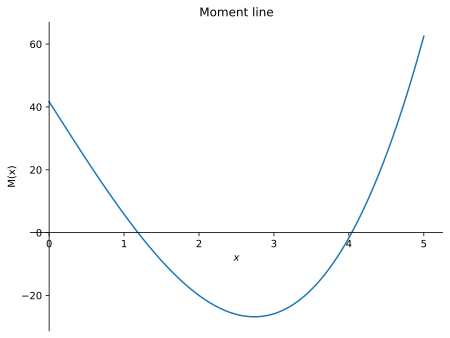

In [9]:
# Plot the moment line to identify the maximum moment
sym.plot(-M.subs(sol1).subs(q_L, 50),(x,0,L),ylabel='M(x)',title='Moment line');

In [10]:
# Obtain the maximum moment at x = L
display(M.subs(sol1).subs(x,L))


-5⋅q_L 
───────
   4   

In [11]:
# Obtain the load corresponding to the first yield moment
q1 = sym.solve(sym.Eq(-M.subs(sol1).subs(x,L),M_p), q_L)[0]
display(q1)

80

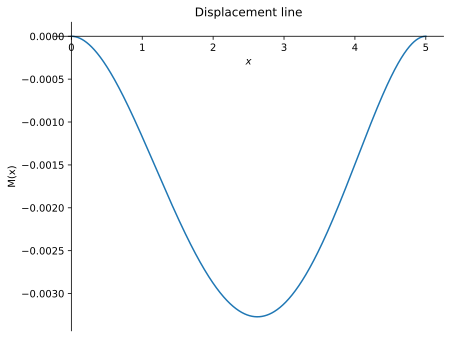

In [12]:
# Plot the displacement line
sym.plot(-w.subs(sol1).subs(q_L, q1),(x,0,L),ylabel='M(x)',title='Displacement line');

In [13]:
# Obtain the displacement at x = L/2
w1 = w.subs(sol1).subs(q_L, q1).subs(x,L/2)
display(w1)
display(w1.evalf())

5/1536

0.00325520833333333

## Plastic behaviour: Beam simply supported on right with $M_p$ working at it

```{figure} ./data_example_2_lecture_3/q1-q2.svg
:align: center
:number:
```

In [14]:
# Define the boundary conditions
eq1 = sym.Eq(w.subs(x,0),0)
eq2 = sym.Eq(w.subs(x,L),0)
eq3 = sym.Eq(phi.subs(x,0),0)
eq4 = sym.Eq(M.subs(x,L),-M_p)

In [15]:
# Solve the integration constants
sol2 = sym.solve([eq1, eq2, eq3, eq4 ], sym.symbols('C1, C2, C3, C4'))
display(sol2)

<IPython.core.display.Math object>

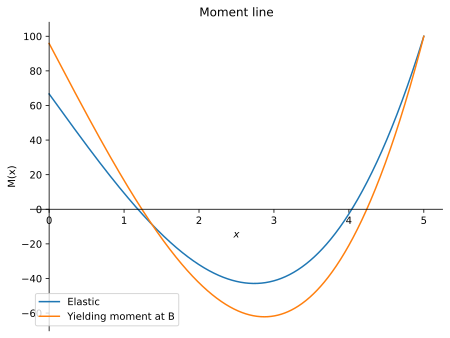

In [16]:
# Plot both moment lines in one figure
sym.plot(
    (-M.subs(sol1).subs(q_L,q1), (x, 0, L), 'Elastic'),
    (-M.subs(sol2).subs(q_L,q1+20), (x, 0, L), 'Yielding moment at B'),
    ylabel='M(x)',
    title='Moment line',
    legend=True
);

In [17]:
# Obtain the maximum moment at x = 0
display(M.subs(sol2).subs(x,0))

     35⋅q_L
50 - ──────
       24  

In [18]:
# Obtain the load corresponding to the yield moment at x = 0
q2 = sym.solve(sym.Eq(-M.subs(sol2).subs(x,0),M_p), q_L)[0]
display(q2)
display(q2.evalf())

720/7

102.857142857143

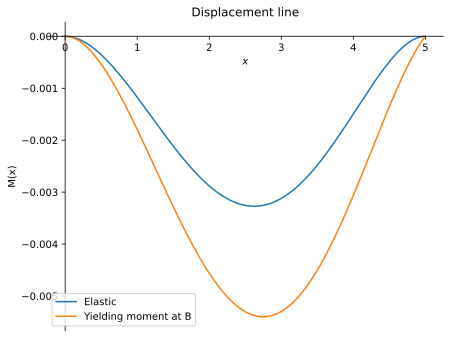

In [19]:
# Plot the displacement line
sym.plot(
    (-w.subs(sol1).subs(q_L,q1), (x, 0, L), 'Elastic'),
    (-w.subs(sol2).subs(q_L, q2), (x, 0, L), 'Yielding moment at B'),
    ylabel='M(x)',
    title='Displacement line',
    legend=True
);

In [20]:
# Obtain the displacement at x = L/2
w2 = w.subs(sol2).subs(q_L, q2).subs(x,L/2)
display(w2)
display(w2.evalf())

 19 
────
3584

0.00530133928571429

## Plastic behaviour: Beam simply supported on both ends with $M_p$ working at it

```{figure} ./data_example_2_lecture_3/q2-q3.svg
:align: center
:number:
```

In [21]:
# Define the boundary conditions
eq1 = sym.Eq(w.subs(x,0),0)
eq2 = sym.Eq(w.subs(x,L),0)
eq3 = sym.Eq(M.subs(x,0),-M_p)
eq4 = sym.Eq(M.subs(x,L),-M_p)

In [22]:
# Solve the integration constants
sol3 = sym.solve([eq1, eq2, eq3, eq4 ], sym.symbols('C1, C2, C3, C4'))
display(sol3)

<IPython.core.display.Math object>

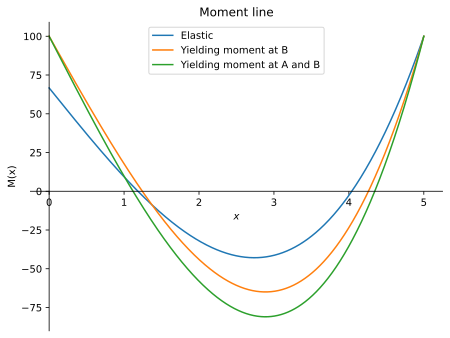

In [23]:
# Plot both moment lines in one figure
sym.plot(
    (-M.subs(sol1).subs(q_L,q1), (x, 0, L), 'Elastic'),
    (-M.subs(sol2).subs(q_L,q2), (x, 0, L), 'Yielding moment at B'),
    (-M.subs(sol3).subs(q_L,q2+10), (x, 0, L), 'Yielding moment at A and B'),
    ylabel='M(x)',
    title='Moment line',
    legend=True
);

In [24]:
# Find the location of the maximum moment
x_M_max = sym.solve(sym.Eq(V.subs(sol3),0),x)[1]
display(x_M_max)

5⋅√3
────
 3  

In [25]:
# Obtain the maximum moment at x = x_M_max
display(M.subs(sol3).subs(x,x_M_max))

25⋅√3⋅q_L      
───────── - 100
   27          

In [26]:
# Obtain the load corresponding to the third yield moment
q3 = sym.solve(sym.Eq(M.subs(sol3).subs(x,x_M_max).subs(x,0),M_p), q_L)[0]
display(q3)
display(q3.evalf())

72⋅√3

124.707658144959

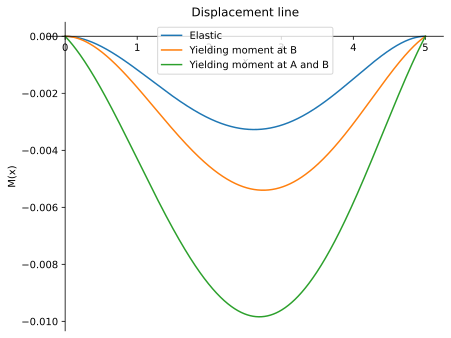

In [27]:
# Plot the displacement line
sym.plot(
    (-w.subs(sol1).subs(q_L,q1), (x, 0, L), 'Elastic'),
    (-w.subs(sol2).subs(q_L, q2), (x, 0, L), 'Yielding moment at B'),
    (-w.subs(sol3).subs(q_L, q3), (x, 0, L), 'Yielding moment at A and B'),
    ylabel='M(x)',
    title='Displacement line',
    legend=True
);

In [28]:
# Obtain the displacement at x = L/2
w3 = w.subs(sol3).subs(q_L, q3).subs(x,L/2).simplify()
display(w3)
display(w3.evalf())

  1    15⋅√3
- ── + ─────
  64   1024 

0.00974683800149723

## Mechanism: Beam simply supported on both ends with $M_p$ working at it and a plastic hinge somewhere in between

```{figure} ./data_example_2_lecture_3/q3-.svg
:align: center
:number:
```

## $q_L-w_C$ diagram

In [29]:
# Obtain the displacements and q values
w_list = [0,w1,w2,w3,w3*2]
q_list = [0,q1,q2,q3,q3]

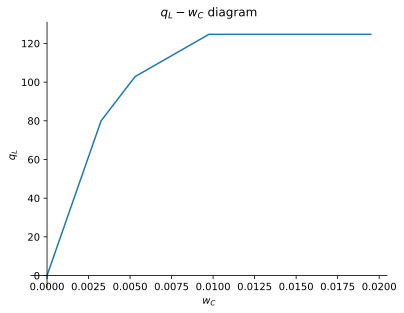

In [30]:
# Plot the q_L-w diagram
plt.plot(w_list,q_list)
plt.xlabel('$w_C $')
plt.ylabel('$q_L $')
plt.title('$q_L-w_C$ diagram')
plt.gca().spines['right'].set_color('none')
plt.gca().spines['top'].set_color('none')
plt.gca().spines['bottom'].set_position('zero')
plt.gca().spines['left'].set_position('zero')